Dataset loaded successfully!
Original shape: (48895, 16)

First 5 rows of data:
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews

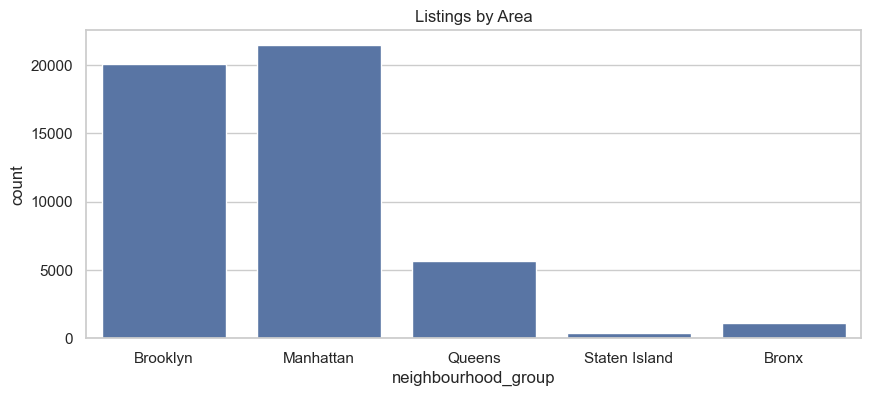

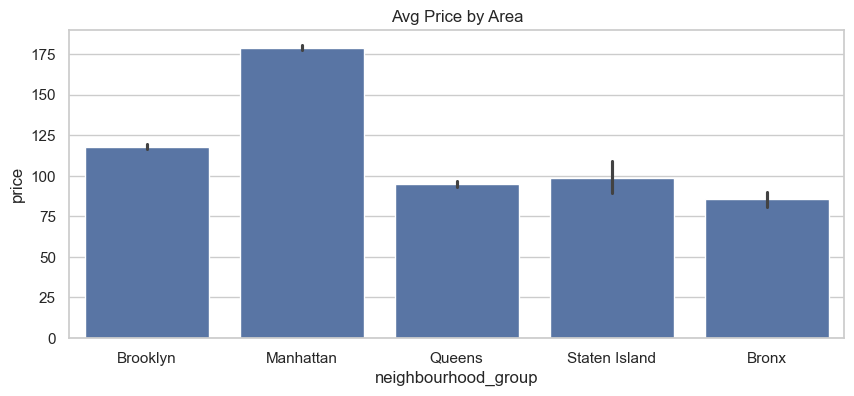

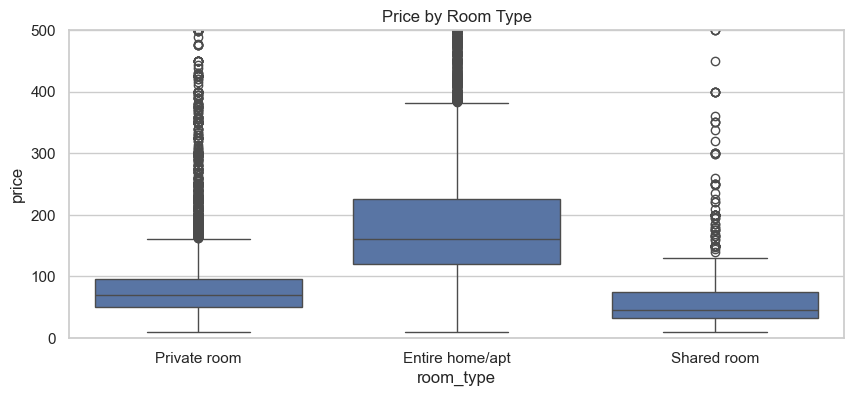

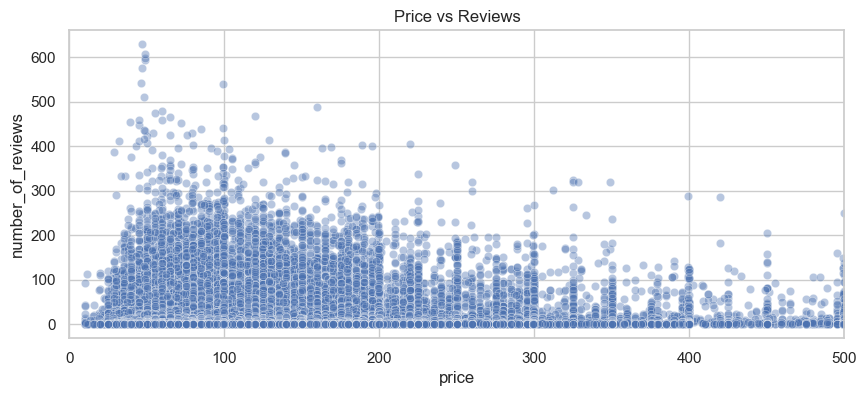

Average price by area:
neighbourhood_group
Bronx             85.36
Brooklyn         117.86
Manhattan        178.94
Queens            95.01
Staten Island     98.58
Name: price, dtype: float64

Average price by room type:
room_type
Entire home/apt    194.61
Private room        84.79
Shared room         67.73
Name: price, dtype: float64

Key Insights:
1. Manhattan has the highest average price.
2. Brooklyn has the most listings.
3. Entire home is the most expensive room type.
4. Cheaper listings tend to have more reviews.


In [8]:
# ACC102 Individual Assignment Track 2
# Airbnb NYC 2019 Analysis

# 1. Problem Definition
# Problem: Analyze NYC Airbnb prices, areas, room types, and reviews
# Users: Travelers and hosts
# Aiming to help travelers find affordable accommodation and assist hosts in setting reasonable prices and understanding market demand

# 2. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set basic plot style
plt.style.use('default')
sns.set(style="whitegrid")

# 3. Load Data
df = pd.read_csv('AB_NYC_2019.csv')

# Show basic information
print("Dataset loaded successfully!")
print("Original shape:", df.shape)

# Show first 5 rows
print("\nFirst 5 rows of data:")
print(df.head())

# Show column names
print("\nColumns in dataset:")
print(df.columns.tolist())

# 4. Basic Data Inspection
print("\nData types and missing values:")
print(df.info())

print("\nBasic statistical summary of price:")
print(df['price'].describe())

# 5. Data Cleaning
print("\n--- Starting Data Cleaning ---")

# Remove duplicate rows
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

# Remove rows with missing values in key columns
df = df.dropna(subset=['price', 'neighbourhood_group', 'room_type', 'number_of_reviews'])
print("After removing missing key values:", df.shape)

# Remove extreme price outliers (keep between $10 and $1000)
df = df[(df['price'] >= 10) & (df['price'] <= 1000)]
print("After filtering abnormal prices:", df.shape)

# 6. Visualization

# Chart 1: Listings by area
plt.figure(figsize=(10,4))
sns.countplot(x='neighbourhood_group', data=df)
plt.title('Listings by Area')
plt.show()

# Chart 2: Average price by area
plt.figure(figsize=(10,4))
sns.barplot(x='neighbourhood_group', y='price', data=df, estimator='mean')
plt.title('Avg Price by Area')
plt.show()

# Chart 3: Price by room type
plt.figure(figsize=(10,4))
sns.boxplot(x='room_type', y='price', data=df)
plt.ylim(0, 500)
plt.title('Price by Room Type')
plt.show()

# Chart 4: Price vs reviews
plt.figure(figsize=(10,4))
sns.scatterplot(x='price', y='number_of_reviews', data=df, alpha=0.4)
plt.xlim(0, 500)
plt.title('Price vs Reviews')
plt.show()

# 7. Summary tables
print("Average price by area:")
print(df.groupby('neighbourhood_group')['price'].mean().round(2))

print("\nAverage price by room type:")
print(df.groupby('room_type')['price'].mean().round(2))

# 8. Key Insights
print("\nKey Insights:")
print("1. Manhattan has the highest average price.")
print("2. Brooklyn has the most listings.")
print("3. Entire home is the most expensive room type.")
print("4. Cheaper listings tend to have more reviews.")